# Loan Risk Analysis & Prediction

## Problem Statement
The goal is to analyze loan data and predict whether a loan will be approved or not based on applicant details.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

## Data Understanding
We load the dataset and explore its structure.

In [ ]:
df=pd.read_csv('loan_approval_dataset.csv')
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [5]:
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [6]:
df=df.drop(['loan_id'],axis=1)

In [ ]:


le = LabelEncoder()

df['loan_status'] = le.fit_transform(df['loan_status'])

### Insight:
The dataset shows the distribution of approved vs rejected loans. This helps understand class balance for model training.

/tmp/ipykernel_27377/1397172620.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='coolwarm')


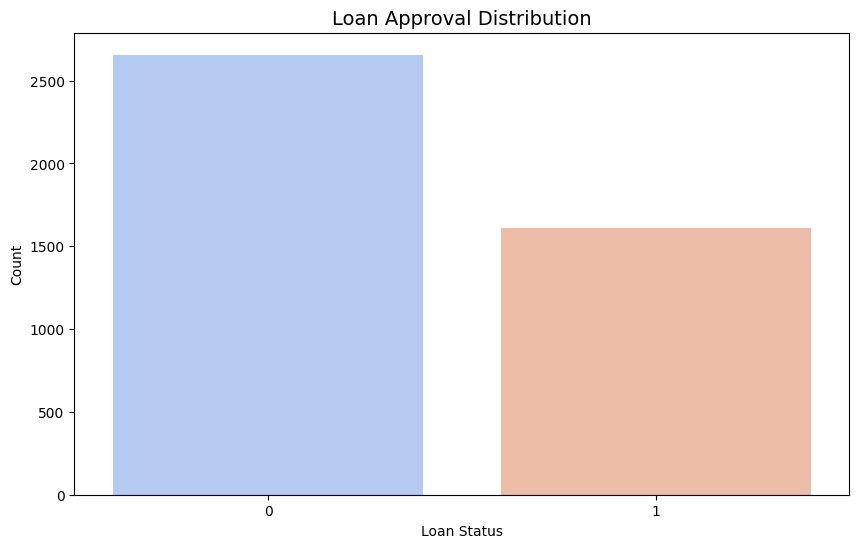

In [ ]:


plt.figure(figsize=(10,6))
sns.countplot(x='loan_status', data=df, palette='coolwarm')
plt.title("Loan Approval Distribution", fontsize=14)
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

### Insight:
Most applicants fall within a specific income range, indicating a concentration of loan applicants in mid-income groups.

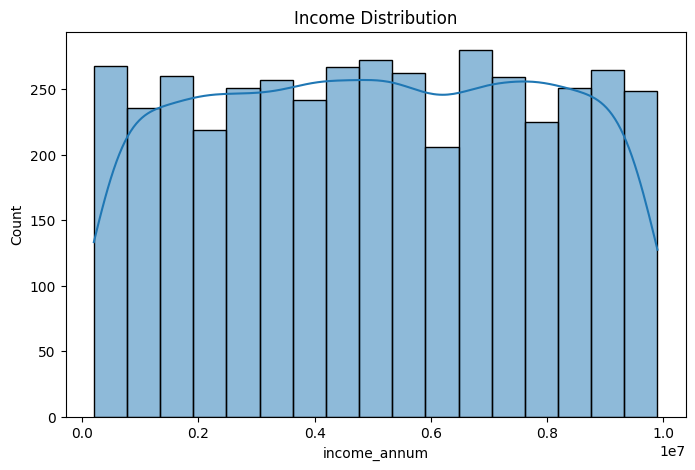

In [38]:

plt.figure(figsize=(8,5))

sns.histplot(df['income_annum'], kde=True)

plt.title("Income Distribution")
plt.show()

### Insight:
Higher income applicants tend to request higher loan amounts, showing a strong positive relationship between income and loan demand.

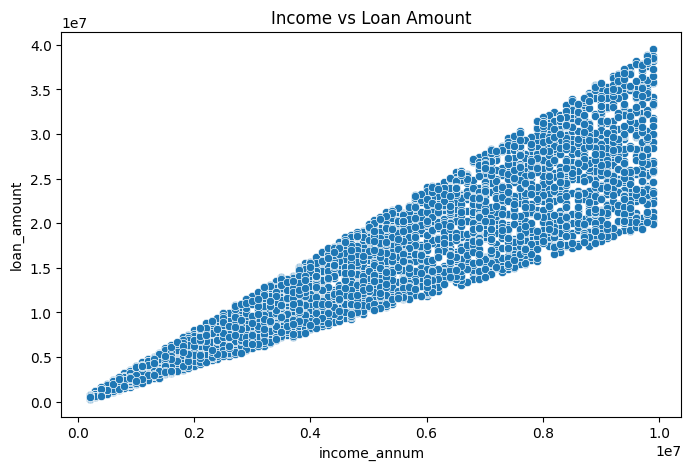

In [39]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='income_annum', y='loan_amount', data=df)

plt.title("Income vs Loan Amount")
plt.show()

### Insight:
The heatmap shows a strong positive correlation between income and loan amount, indicating that applicants with higher income tend to request larger loans. The cibil_score has a noticeable relationship with loan status, suggesting it plays an important role in loan approval. Asset-related features also show moderate correlation with loan amount.

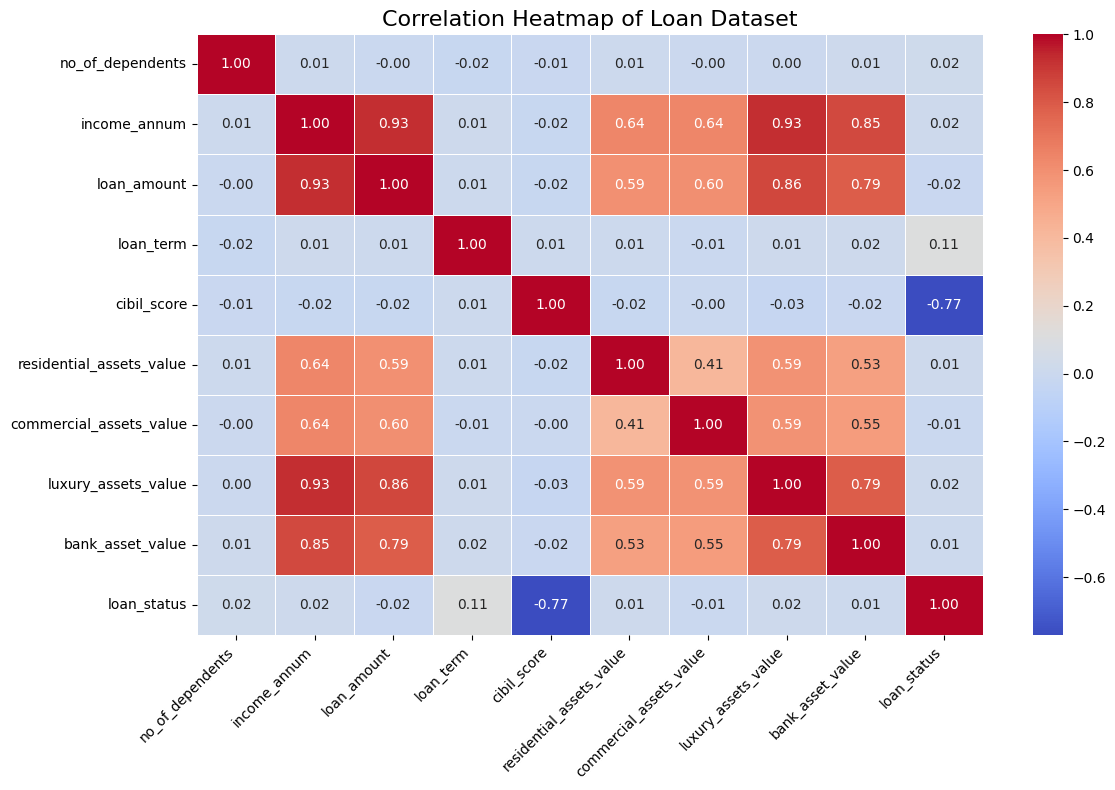

In [36]:

df_numeric = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))

sns.heatmap(
    df_numeric.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Loan Dataset", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:

X=df.drop("loan_status",axis=1)
y=df["loan_status"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
print(X_train.shape)
print(X_test.shape)

(3415, 11)
(854, 11)


In [13]:
cat_cols=["education","self_employed"]
num_cols=X.select_dtypes(include=['int64','float64']).columns

##  Model Building
Using sklearn Pipeline with preprocessing + Random Forest classifier.

In [15]:
num_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

In [16]:
cat_pipeline=Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))

])

In [17]:
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_cols),
    ('cat',cat_pipeline,cat_cols)
])

In [18]:
pipe=Pipeline([
    ('preprocess',preprocessor),
    ('model',RandomForestClassifier(random_state=42))
])

In [19]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['education',
                                                   'self_employed'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [20]:
y_pred=pipe.predict(X_test)
print(y_pred)

[1 0 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 1 1 0
 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0
 1 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 0 1 0 0 0 0
 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 1 0
 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1
 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 0 1
 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0
 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 0 1 0
 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 0 0
 0 1 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1
 1 0 0 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 1 1 0 0 1 0 0 1
 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 1 0 0 1 1 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 1 

##  Model Evaluation
Classification report, confusion matrix, and cross-validation scores.


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[529   7]
 [  7 311]]


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       536
           1       0.98      0.98      0.98       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



##  Hyperparameter Tuning
GridSearchCV to find best model parameters.

In [23]:
imp=pipe.named_steps['model'].feature_importances_
feature_names=pipe.named_steps['preprocess'].get_feature_names_out()
feat_imp=pd.DataFrame({
    'feature':feature_names,
    'Importance':imp
})

print(feat_imp.head(10))

                         feature  Importance
0          num__no_of_dependents    0.009600
1              num__income_annum    0.018784
2               num__loan_amount    0.030967
3                 num__loan_term    0.059518
4               num__cibil_score    0.795252
5  num__residential_assets_value    0.020334
6   num__commercial_assets_value    0.018544
7       num__luxury_assets_value    0.020324
8          num__bank_asset_value    0.017748
9       cat__education_ Graduate    0.001935


In [ ]:
scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring='f1'
)

print("Scores:", scores)
print("Mean F1 Score:", scores.mean())

Scores: [0.97169811 0.97305864 0.98289269 0.97169811 0.97196262]
Mean F1 Score: 0.9742620341669473


In [ ]:
params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5]
}

grid = GridSearchCV(
    pipe,
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [26]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [27]:
import pickle
pickle.dump(best_model, open("model1.pkl","wb"))

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

